In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2025-11-17 15:54:38.607271


Okay so basically we have four branches of the data. Nuclear and whole cell, and with and without the transgenes. It makes sense to make sure the scVI latent rep etc. is not being influenced by the GFP etc.

# Train scVI model

In [2]:
import os
from pathlib import Path
import scanpy as sc
from scipy.sparse import issparse, csr_matrix
import scvi
import numpy as np
from collections import Counter
import anndata as ad
import matplotlib.pyplot as plt
from lightning.pytorch import seed_everything
import random
import torch
import sys
import session_info

/home/workspace/environment/sc-charter/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
random.seed(0)
seed_everything(0)

scvi.settings.seed = 0
scvi.settings.num_workers = 32

Seed set to 0
Seed set to 0


## Set paths, import data

In [4]:
base_dir = Path('/home/workspace/projects/drg')

input_dir = base_dir / 'data/h5ad/export_01/04_filtered' # edit to 4b or something
scvi_dir = base_dir / 'scvi/models'
output_dir = base_dir/ 'data/h5ad/export_02/01_scvi'

os.makedirs(output_dir, exist_ok=True)

In [5]:
path_whole   = input_dir / "adata-filtered_whole.h5ad"
path_nuclear = input_dir / "adata-filtered_nuclear.h5ad"

In [6]:
adata = sc.read_h5ad(path_whole)
bdata = sc.read_h5ad(path_nuclear)

## Prepare adata

In [7]:
# Save counts layer for scVI and downstream processing
adata.X = adata.layers['counts'].copy()
bdata.X = bdata.layers['counts'].copy()

In [8]:
for n, a in zip(["adata", "bdata"], [adata, bdata]):
    if not issparse(a.X):
        a.X = csr_matrix(a.X)
        print(f"Converted {n} to sparse CSR")

Converted bdata to sparse CSR


In [9]:
adata.X[:5, :5].toarray()

array([[ 0.,  2.,  0.,  2.,  0.],
       [ 3., 20.,  1., 25.,  0.],
       [ 1.,  1.,  5., 13.,  0.],
       [ 0.,  1.,  0.,  0.,  0.],
       [ 0.,  4.,  0.,  9.,  0.]], dtype=float32)

In [10]:
bdata.X[:5, :5].toarray()

array([[0., 2., 0., 2., 0.],
       [2., 3., 0., 1., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])

In [11]:
print('adata.X is sparse:', issparse(adata.X))
print('adata.X has only whole numbers:', np.all(adata.X.data == np.round(adata.X.data)))  # True if all values are whole numbers

adata.X is sparse: True
adata.X has only whole numbers: True


In [12]:
adata_all = adata.copy()
bdata_all = bdata.copy()

In [13]:
def remove_transgenes(adata, pattern="Seq"):
    """
    Remove the five transgenes, which all have "Seq" string
    """
    print(f"\nProcessing: {getattr(adata, 'uns', {}).get('name', 'AnnData')}")
    print(f"Initial # genes: {adata.n_vars}")
    
    transgenes = adata.var_names[adata.var_names.str.contains(pattern, case=False, na=False)]
    print(f"Found {len(transgenes)} transgenes: {list(transgenes)[:10]}{' ...' if len(transgenes) > 10 else ''}")

    adata_filtered = adata[:, ~adata.var_names.isin(transgenes)].copy()
    print(f"Remaining genes: {adata_filtered.n_vars}")

    return adata_filtered

In [14]:
adata_nt = remove_transgenes(adata, pattern="Seq")
bdata_nt = remove_transgenes(bdata, pattern="Seq")


Processing: AnnData
Initial # genes: 480
Found 5 transgenes: ['Cre_Seq5', 'EGFP_Seq1', 'Flp_Seq4', 'mCherry_Seq3', 'tdTomato_Seq2']
Remaining genes: 475

Processing: AnnData
Initial # genes: 480
Found 5 transgenes: ['Cre_Seq5', 'EGFP_Seq1', 'Flp_Seq4', 'mCherry_Seq3', 'tdTomato_Seq2']
Remaining genes: 475


# scVI

* Model A - adata_all: whole cell, all genes
* Model B - adata_nt: whole cell, no transgenes
* Model C - bdata_all: nuclear, all genes
* Model D - bdata_nt: nuclear, no transgenes

In [15]:
def train_scvi_model(adata, model_name, scvi_dir, output_dir, latent_key_suffix=""):
    """
    Train sequential scVI models
    """
    print(f"\n Training {model_name}")

    # Setup for scVI
    scvi.model.SCVI.setup_anndata(
        adata,
        layer="counts",
        batch_key="slide"
    )

    # Initialize model
    model = scvi.model.SCVI(
        adata,
        n_layers=2,
        n_latent=30,
        gene_likelihood="nb"
    )

    # Train model
    model.train(
        early_stopping=True,
        #accelerator="gpu",
        early_stopping_patience=5,
        early_stopping_min_delta=1e-4,
        enable_progress_bar=True
    )

    # Save model
    model_save_dir = os.path.join(scvi_dir, model_name)
    model.save(model_save_dir)

    # Plot ELBO loss curves
    plt.plot(model.history["elbo_train"], label="Train ELBO Loss")
    plt.plot(model.history["elbo_validation"], label="Validation ELBO Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title(f"{model_name} SCVI Training Loss")
    plt.tight_layout()
    plt.show()

    # Add latent representation
    latent_key = f"X_scVI_{model_name}"
    adata.obsm[latent_key] = model.get_latent_representation(adata).astype(np.float32)

    # Save AnnData
    os.makedirs(output_dir, exist_ok=True)
    filename = os.path.join(output_dir, f"{model_name}_adata-scvi.h5ad")
    adata.write_h5ad(filename, compression="gzip")

    print(f"Saved model + latent to {filename} ({latent_key})")

    return model, adata


 Training ModelA_whole_all


/home/workspace/environment/sc-charter/lib/python3.12/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)
Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
/home/workspace/environment/sc-charter/lib/python3.12/site-packages/lightni

Epoch 82/82: 100%|██████████| 82/82 [08:26<00:00,  6.30s/it, v_num=1, train_loss_step=255, train_loss_epoch=248]

`Trainer.fit` stopped: `max_epochs=82` reached.


Epoch 82/82: 100%|██████████| 82/82 [08:26<00:00,  6.18s/it, v_num=1, train_loss_step=255, train_loss_epoch=248]


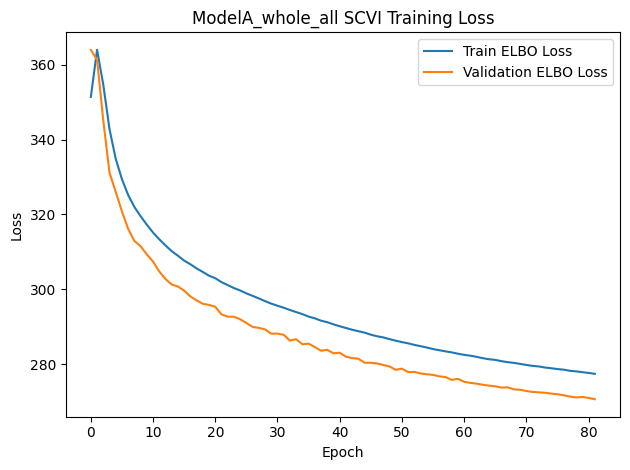

/home/workspace/environment/sc-charter/lib/python3.12/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)
Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
/home/workspace/environment/sc-charter/lib/python3.12/site-packages/lightni

Saved model + latent to /home/workspace/projects/drg/data/h5ad/export_02/01_scvi/ModelA_whole_all_adata-scvi.h5ad (X_scVI_ModelA_whole_all)

 Training ModelB_whole_noTG
Epoch 82/82: 100%|██████████| 82/82 [08:30<00:00,  6.23s/it, v_num=1, train_loss_step=232, train_loss_epoch=245]

`Trainer.fit` stopped: `max_epochs=82` reached.


Epoch 82/82: 100%|██████████| 82/82 [08:30<00:00,  6.23s/it, v_num=1, train_loss_step=232, train_loss_epoch=245]


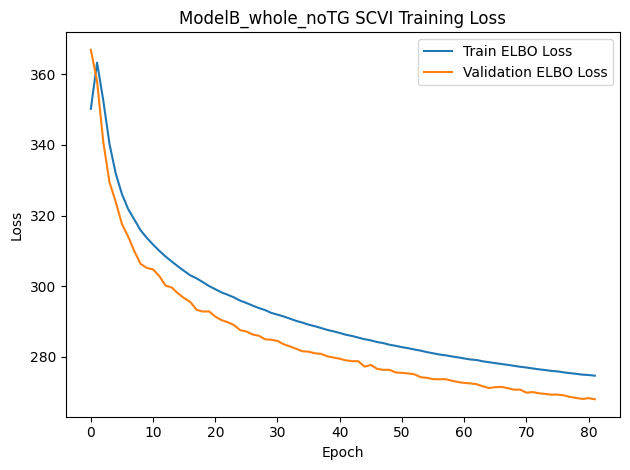

Saved model + latent to /home/workspace/projects/drg/data/h5ad/export_02/01_scvi/ModelB_whole_noTG_adata-scvi.h5ad (X_scVI_ModelB_whole_noTG)

 Training ModelC_nuclear_all


/home/workspace/environment/sc-charter/lib/python3.12/abc.py:119: FutureWarning: SparseDataset is deprecated and will be removed in late 2024. It has been replaced by the public classes CSRDataset and CSCDataset.

For instance checks, use `isinstance(X, (anndata.experimental.CSRDataset, anndata.experimental.CSCDataset))` instead.

For creation, use `anndata.experimental.sparse_dataset(X)` instead.

  return _abc_instancecheck(cls, instance)
/home/workspace/environment/sc-charter/lib/python3.12/site-packages/scvi/model/_scvi.py:155: UserWarning: This dataset has some empty cells, this might fail inference.Data should be filtered with `scanpy.pp.filter_cells()`
  library_log_means, library_log_vars = _init_library_size(
Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage ma

Epoch 82/82: 100%|██████████| 82/82 [08:31<00:00,  6.42s/it, v_num=1, train_loss_step=151, train_loss_epoch=160]

`Trainer.fit` stopped: `max_epochs=82` reached.


Epoch 82/82: 100%|██████████| 82/82 [08:31<00:00,  6.23s/it, v_num=1, train_loss_step=151, train_loss_epoch=160]


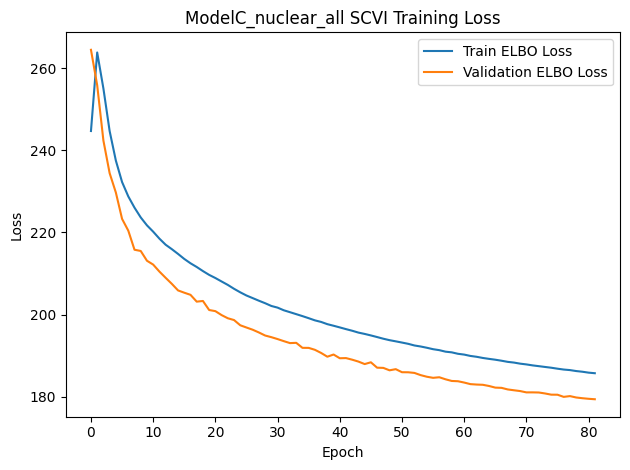

Saved model + latent to /home/workspace/projects/drg/data/h5ad/export_02/01_scvi/ModelC_nuclear_all_adata-scvi.h5ad (X_scVI_ModelC_nuclear_all)

 Training ModelD_nuclear_noTG


/home/workspace/environment/sc-charter/lib/python3.12/site-packages/scvi/model/_scvi.py:155: UserWarning: This dataset has some empty cells, this might fail inference.Data should be filtered with `scanpy.pp.filter_cells()`
  library_log_means, library_log_vars = _init_library_size(
Trainer will use only 1 of 4 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=4)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1,2,3]
/home/workspace/environment/sc-charter/lib/python3.12/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of

Epoch 82/82: 100%|██████████| 82/82 [08:29<00:00,  6.13s/it, v_num=1, train_loss_step=166, train_loss_epoch=158]

`Trainer.fit` stopped: `max_epochs=82` reached.


Epoch 82/82: 100%|██████████| 82/82 [08:29<00:00,  6.22s/it, v_num=1, train_loss_step=166, train_loss_epoch=158]


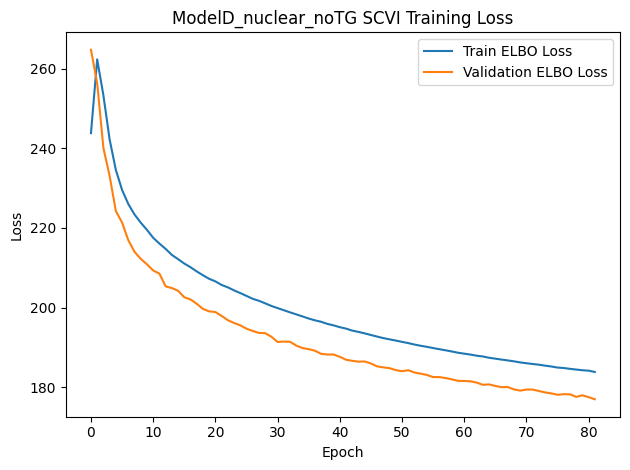

Saved model + latent to /home/workspace/projects/drg/data/h5ad/export_02/01_scvi/ModelD_nuclear_noTG_adata-scvi.h5ad (X_scVI_ModelD_nuclear_noTG)


SCVI model with the following parameters: 
n_hidden: 128, n_latent: 30, n_layers: 2, dropout_rate: 0.1, dispersion: gene, gene_likelihood: nb, 
latent_distribution: normal.
Training status: Trained
Model's adata is minified?: False

(,
 AnnData object with n_obs × n_vars = 97017 × 475
     obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'nuclear_fraction', 'doublet_scores', 'predicted_doublets', 'batch', 'slide', '_scvi_batch', '_scvi_labels'
     uns: 'log1p', '_scvi_uuid', '_scvi_manager_uuid'
     obsm: 'spatial', 'X_scVI_ModelD_nuclear_noTG'
     layers: 'counts', 'log1p', 'normalized_1e6')

In [16]:
train_scvi_model(adata_all, "ModelA_whole_all", scvi_dir, output_dir)
train_scvi_model(adata_nt,  "ModelB_whole_noTG", scvi_dir, output_dir)
train_scvi_model(bdata_all, "ModelC_nuclear_all", scvi_dir, output_dir)
train_scvi_model(bdata_nt,  "ModelD_nuclear_noTG", scvi_dir, output_dir)

## Session info

In [17]:
print('active IDE: sc-spatial-gpu')
print('active conda environment:', os.path.basename(sys.prefix))
session_info.show()

active IDE: sc-spatial-gpu
active conda environment: sc-charter


/home/workspace/environment/sc-charter/lib/python3.12/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)
